# IMPORTS

In [1]:
# Import
import pandas as pd
import os
def start_workspace():
    curr = os.getcwd()
    while curr != os.path.dirname(curr):
        potential_ini = os.path.join(curr, 'src', 'ini.py')
        if os.path.exists(potential_ini):
            get_ipython().run_line_magic('run', f'-i "{potential_ini}"')
            return True
        curr = os.path.dirname(curr)
    return False

if not start_workspace():
    print("❌ Konnte 'src/ini.py' nicht finden. Prüfe die Ordnerstruktur!")

%load_ext autoreload
%autoreload 2

✅ Universal workspace ready!
📍 Main folder: /Users/cristallagus/Desktop/GitHub/weebet/_onboarding_data
📦 Modules loaded: sql_database_conectors_image, pre_eda_words, sql_database_offline_download, sql_database_offline_in_df, pre_eda_data, translator, pandas_deepseek_offline_agent


# Connect to the database

/Users/cristallagus/Desktop/GitHub/weebet/_onboarding_data/src/sql_database_conectors_image.py:97: SAWarning: Did not recognize type 'geometry' of column 'geom_point'
  columns = inspector.get_columns(table_name)


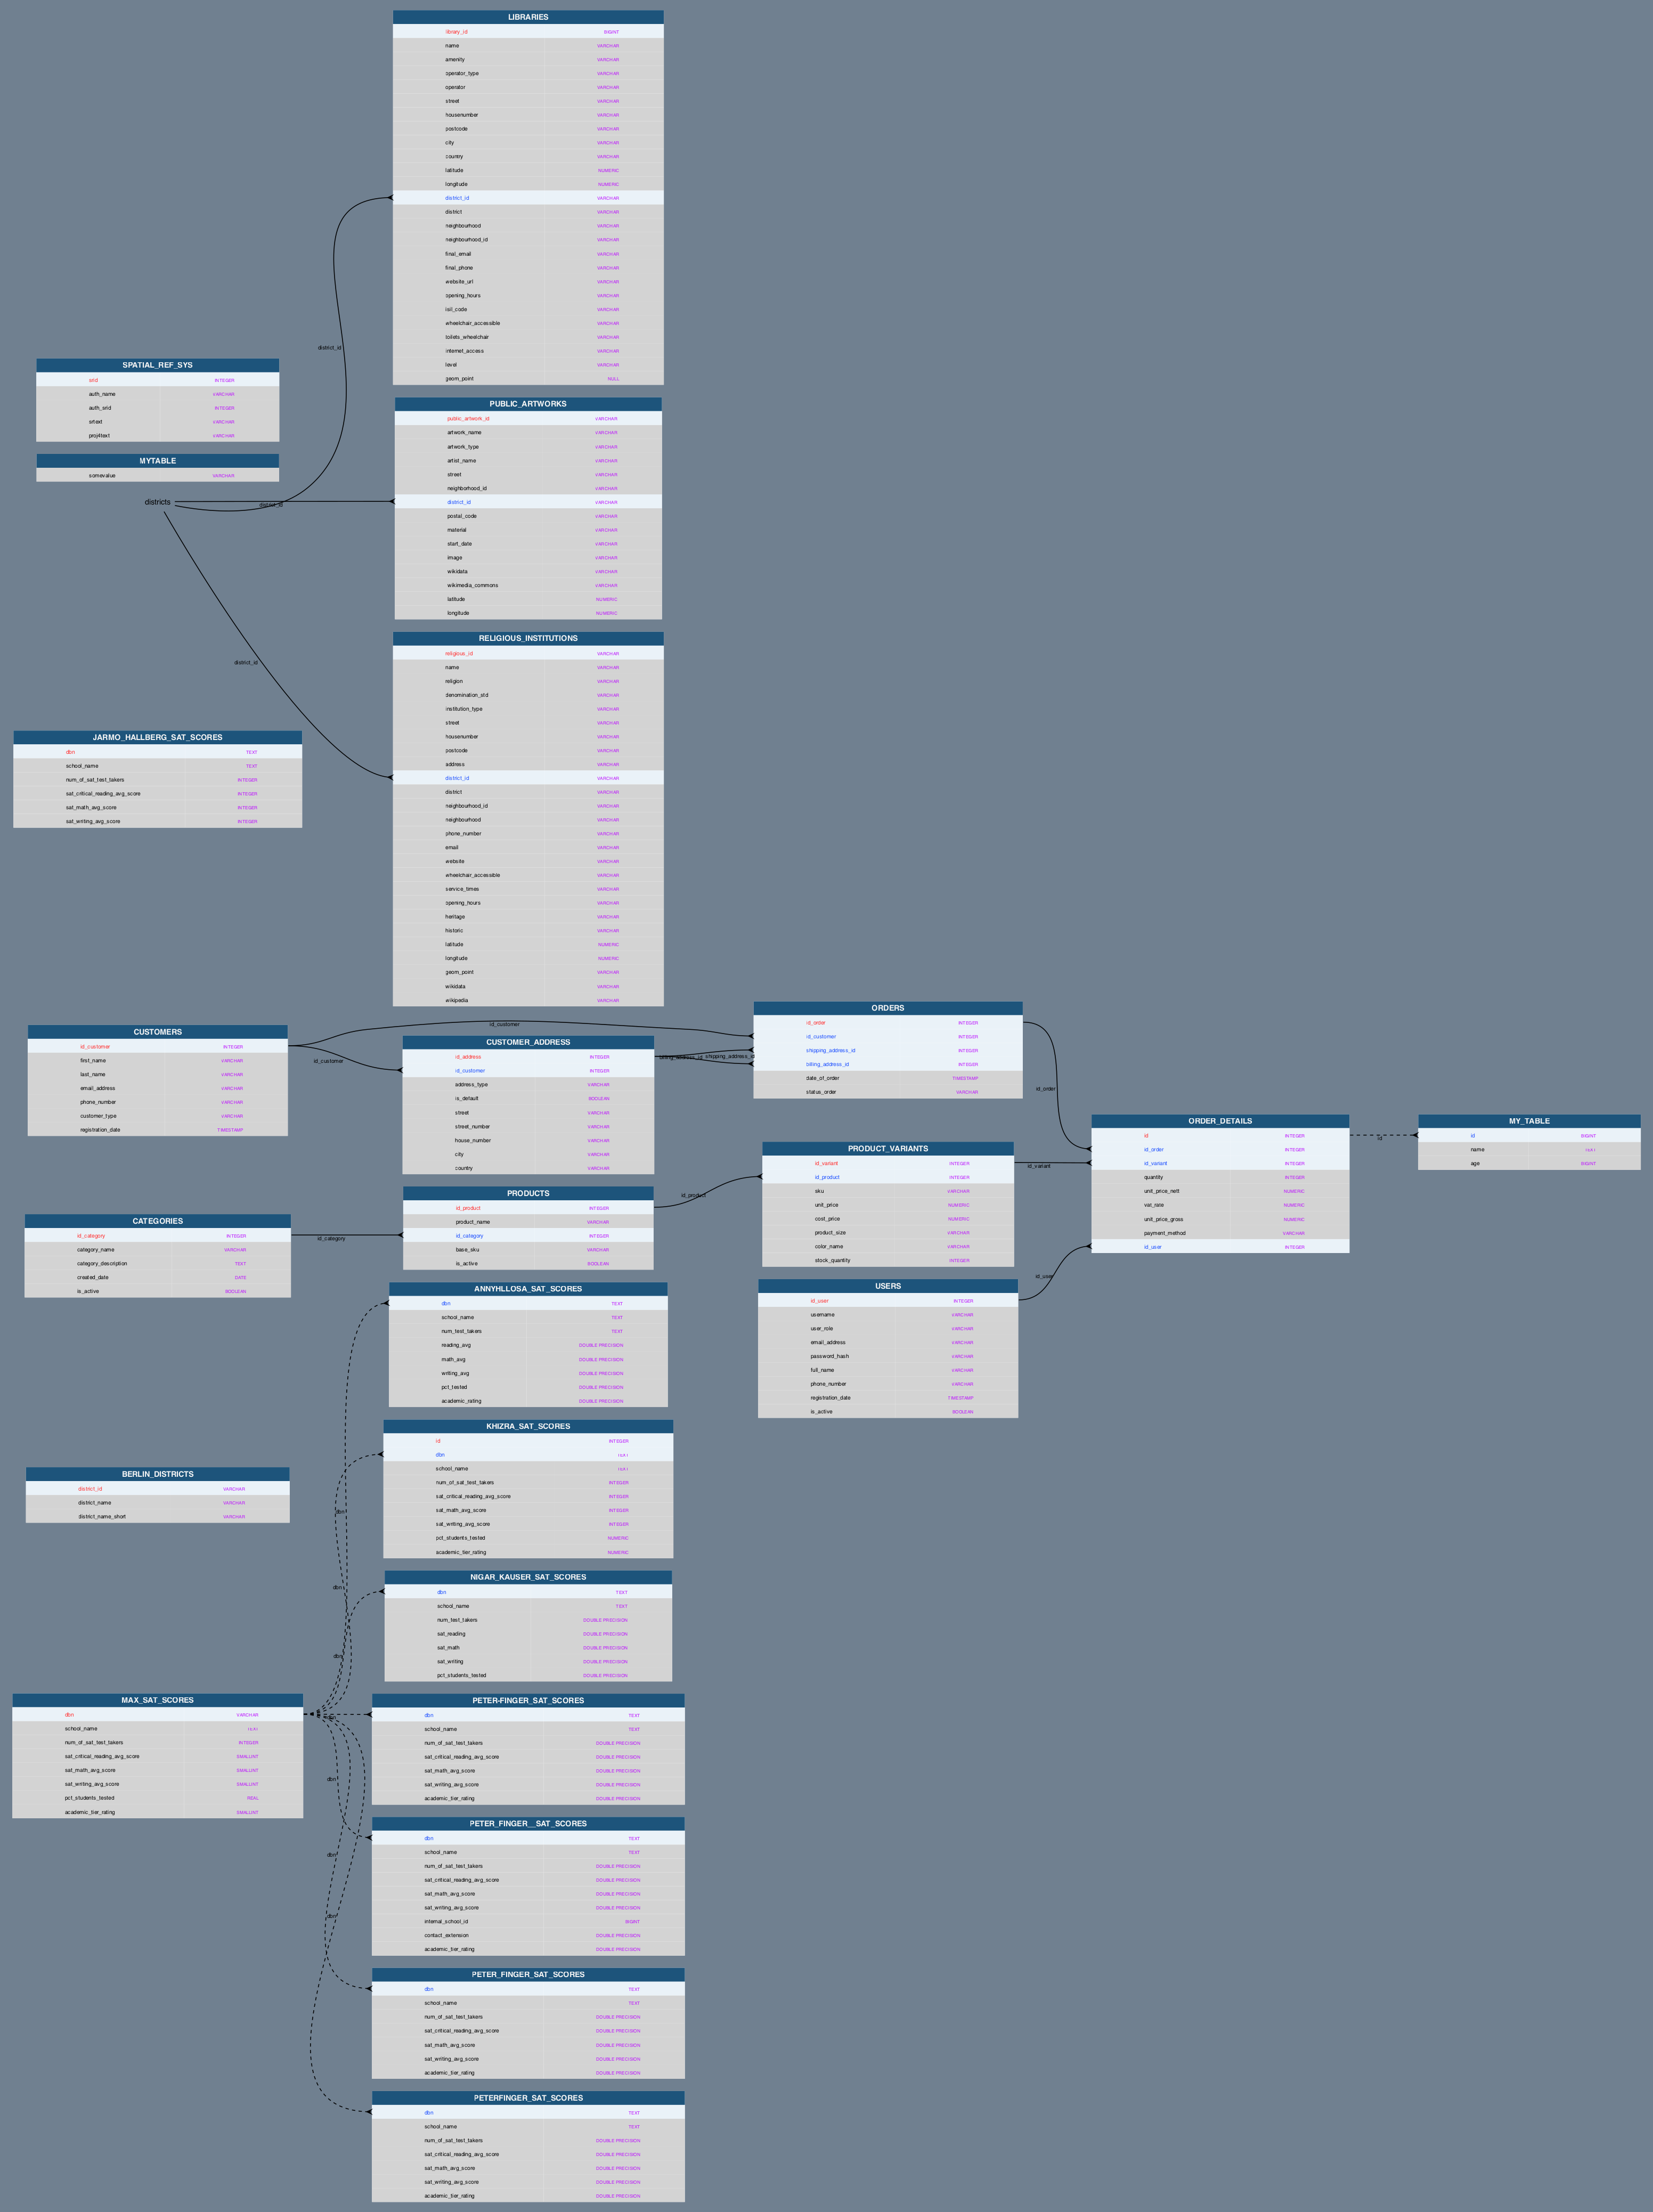

In [ ]:
sql_conect_image(open(os.path.join(os.getcwd().split('_onboarding_data')[0], '_onboarding_data/src/SQL_LINK_.txt'), 'r').read().strip())

In [ ]:
sql_query(f"sqlite:////{os.path.join(os.getcwd().split('_onboarding_data')[0], '_onboarding_data/notebook/replizierte_daten.sqlite')}")

🔍 Erkannt: 🖥️  Lokal  (sqlite:////)
✅ Datenbank geladen: sqlite:////Users/cristallagus/Desktop/GitHub/weebet/_onboarding_data/notebook/replizierte_daten.sqlite
📄 Pfad gespeichert: /Users/cristallagus/Desktop/GitHub/weebet/_onboarding_data/src/SQL_LINK.txt
👉 Du kannst jetzt query_sql("SELECT...") nutzen.


Wie viele Schulen gibt es in jedem Stadtbezirk?

---

How many schools are there in each borough?

In [3]:
sql_query("""
SELECT 
    borough, 
    COUNT(*) AS school_count
FROM 
    high_school_directory
GROUP BY 
    borough
ORDER BY 
    school_count DESC;
""")

,borough,school_count
0,Brooklyn,121
1,Bronx,118
2,Manhattan,106
3,Queens,80
4,Staten Island,10


- Die Daten zeigen eine klare Konzentration in Brooklyn (121 Schulen) und den Bronx (118), während Staten Island mit nur 10 Schulen das Schlusslicht bildet.

---

- The data shows a high concentration of schools in Brooklyn (121) and the Bronx (118), while Staten Island has the fewest with only 10 schools.

Wie hoch ist der durchschnittliche Anteil von Englischlernenden (ELL) pro Stadtbezirk?

---

What is the average % of English Language Learners (ELL) per borough?

In [4]:
sql_query("""
SELECT 
    hsd.borough, 
    AVG(sd.ell_percent) AS average_ell_percent
FROM 
    high_school_directory hsd
JOIN 
    school_demographics sd ON hsd.dbn = sd.dbn
WHERE 
    sd.schoolyear = 20112012
GROUP BY 
    hsd.borough
ORDER BY 
    average_ell_percent DESC;
""")

,borough,average_ell_percent
0,Manhattan,11.96


- Manhattan führt die Liste mit einem durchschnittlichen ELL-Anteil von 11,96 % an. Dies deutet auf eine sehr diverse Schülerschaft hin, die spezifische sprachliche Unterstützung benötigt.

---

- Manhattan leads with an average ELL percentage of 11.96%, indicating a diverse student body that requires specific linguistic support and bilingual resources.

Schreiben Sie anhand der Daten aus der Schuldemografie und dem Gymnasialverzeichnis eine Abfrage, um die drei Schulen in jedem Stadtbezirk mit dem höchsten Anteil an Schülern mit sonderpädagogischem Förderbedarf (sped_percent) zu finden.

---

Using the data from the school demographics and high school directory, write a query to find the top 3 schools in each borough with the highest percentage of special education students (sped_percent)

In [5]:
sql_query("""
WITH RankedSchools AS (
    SELECT 
        hsd.borough,
        hsd.school_name,
        sd.sped_percent,
        ROW_NUMBER() OVER (
            PARTITION BY hsd.borough 
            ORDER BY sd.sped_percent DESC
        ) as rank
    FROM 
        high_school_directory hsd
    JOIN 
        school_demographics sd ON hsd.dbn = sd.dbn
    WHERE 
        sd.schoolyear = 20112012
)
SELECT 
    borough,
    school_name,
    sped_percent
FROM 
    RankedSchools
WHERE 
    rank <= 3
ORDER BY 
    borough, 
    sped_percent DESC;
""")

,borough,school_name,sped_percent
0,Manhattan,East Side Community School,26.4
1,Manhattan,Marta Valle High School,25.9
2,Manhattan,Henry Street School for International Studies,24.9


- In Manhattan ragen besonders die East Side Community School (26,4 %) und die Marta Valle High School (25,9 %) heraus. Diese Schulen leisten einen überproportional großen Beitrag zur Unterstützung von Schülern mit speziellen Bedürfnissen.

---

- In Manhattan, schools like East Side Community School (26.4%), Marta Valle High School (25.9%), and Henry Street School (24.9%) stand out for their high focus on inclusive education and specialized student support.

# Insgesamt bestätigen die Daten eine hohe Schulkonzentration in Brooklyn und der Bronx, während Manhattan den höchsten Bedarf an spezieller Sprachförderung (11,96 % ELL) und Programmen für inklusive Bildung (bis zu 26,4 % SPED) aufweist.

---

# Overall, the data confirms a high concentration of schools in Brooklyn and the Bronx, while Manhattan shows the highest demand for specialized language (11.96% ELL) and inclusive education programs (up to 26.4% SPED).